# Assignment 5: Exploratory Data Analysis with Pandas

# Student Name: Mohammad Tamim Hamkar

Task 1: Load the Titanic dataset

In [9]:
# Load the Titanic dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Titanic dataset loaded successfully.")

Titanic dataset loaded successfully.


Task 2: Inspect the dataset

In [3]:
# Inspect the Titanic dataset

print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

print("Data types:")
print(df.dtypes)

print("Statistical summary:")
display(df.describe())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Last 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
Statistical summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Task 3: Clean and preprocess the data

In [13]:
# Clean and preprocess the data

# Create categorical feature for Pclass
df["Pclass_Category"] = df["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

# Create categorical feature for Cabin
df["Cabin_Category"] = df["Cabin"].apply(
    lambda x: "Cabin Assigned" if pd.notna(x) else "No Cabin"
)

# Check missing values in Age
print("Missing Age values before:", df["Age"].isnull().sum())

# Fill missing Age values with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Age values after:", df["Age"].isnull().sum())

# Create Family feature
df["Family"] = df["SibSp"] + df["Parch"] + 1

# Display the new features
display(df[["Pclass", "Pclass_Category", "Cabin",
            "Cabin_Category", "Age", "Family"]].head())

Missing Age values before: 177
Missing Age values after: 0


,Pclass,Pclass_Category,Cabin,Cabin_Category,Age,Family
0,3,Third Class,NaN,No Cabin,22.0,2
1,1,First Class,C85,Cabin Assigned,38.0,2
2,3,Third Class,NaN,No Cabin,26.0,1
3,1,First Class,C123,Cabin Assigned,35.0,2
4,3,Third Class,NaN,No Cabin,35.0,1


Task 4: Identify specific data points

In [5]:
# Find passengers with the highest fare and largest family size

# Passenger(s) with the highest fare
highest_fare = df[df["Fare"] == df["Fare"].max()]
print("Passenger(s) with the highest fare:")
display(highest_fare[["Name", "Fare"]])

# Passenger(s) with the largest family size
largest_family = df[df["Family"] == df["Family"].max()]
print("Passenger(s) with the largest family size:")
display(largest_family[["Name", "Family"]])

Passenger(s) with the highest fare:


,Name,Fare
258,"Ward, Miss. Anna",512.3292
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292
737,"Lesurer, Mr. Gustave J",512.3292


Passenger(s) with the largest family size:


,Name,Family
159,"Sage, Master. Thomas Henry",11
180,"Sage, Miss. Constance Gladys",11
201,"Sage, Mr. Frederick",11
324,"Sage, Mr. George John Jr",11
792,"Sage, Miss. Stella Anna",11
846,"Sage, Mr. Douglas Bullen",11
863,"Sage, Miss. Dorothy Edith ""Dolly""",11


Task 5: Demonstrate Pandas Series and DataFrame functionalities

In [6]:
# Demonstrate Pandas Series and DataFrame functionalities

# Create a Pandas Series
age_series = df["Age"]
print("Age Series:")
display(age_series.head())

# Create a DataFrame with selected columns
passenger_df = df[["Name", "Sex", "Age", "Fare"]]
print("Passenger DataFrame:")
display(passenger_df.head())

# Indexing - select the first passenger
print("First passenger:")
display(passenger_df.iloc[0])

# Slicing - select the first five passengers
print("First five passengers:")
display(passenger_df.iloc[0:5])

Age Series:


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


Passenger DataFrame:


,Name,Sex,Age,Fare
0,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,"Allen, Mr. William Henry",male,35.0,8.0500


First passenger:


,0
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
Fare,7.25


First five passengers:


,Name,Sex,Age,Fare
0,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,"Allen, Mr. William Henry",male,35.0,8.0500


Task 6: Create a multi-index DataFrame of survival rates by Sex and Pclass

In [7]:
# Create a multi-index DataFrame of survival rates by Sex and Pclass

survival_multiindex = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .to_frame(name="Survival_Rate")
)

display(survival_multiindex)

Survival_Rate
Sex    Pclass               
female 1            0.968085
       2            0.921053
       3            0.500000
male   1            0.368852
       2            0.157407
       3            0.135447

Task 7: Create various visualizations

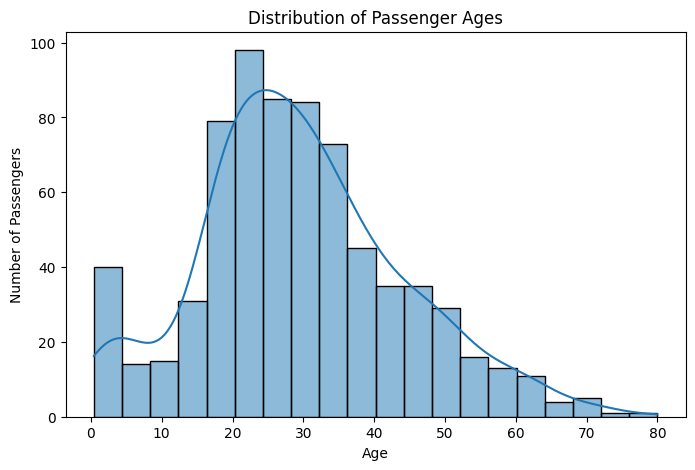

In [10]:
# Histogram of passenger ages

plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

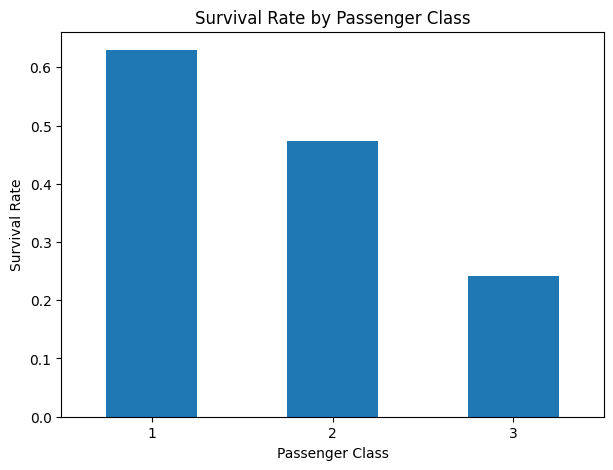

In [11]:
# Bar plot of survival rates by passenger class

survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(7, 5))
survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

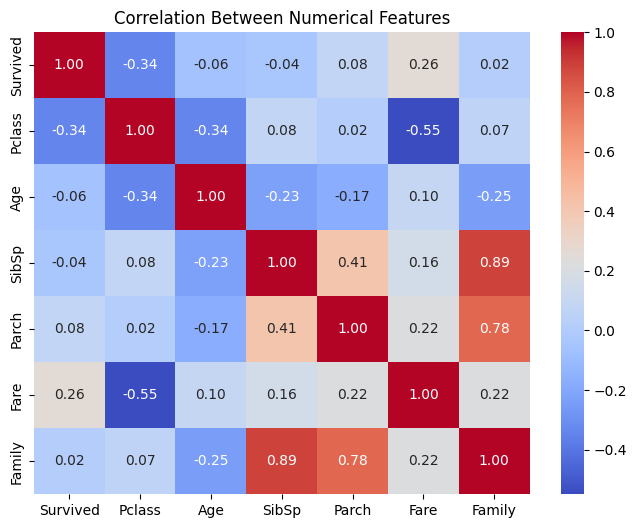

In [14]:
# Heatmap of correlations between numerical features

numerical_features = df[
    ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Family"]
]

correlation_matrix = numerical_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Features")
plt.show()

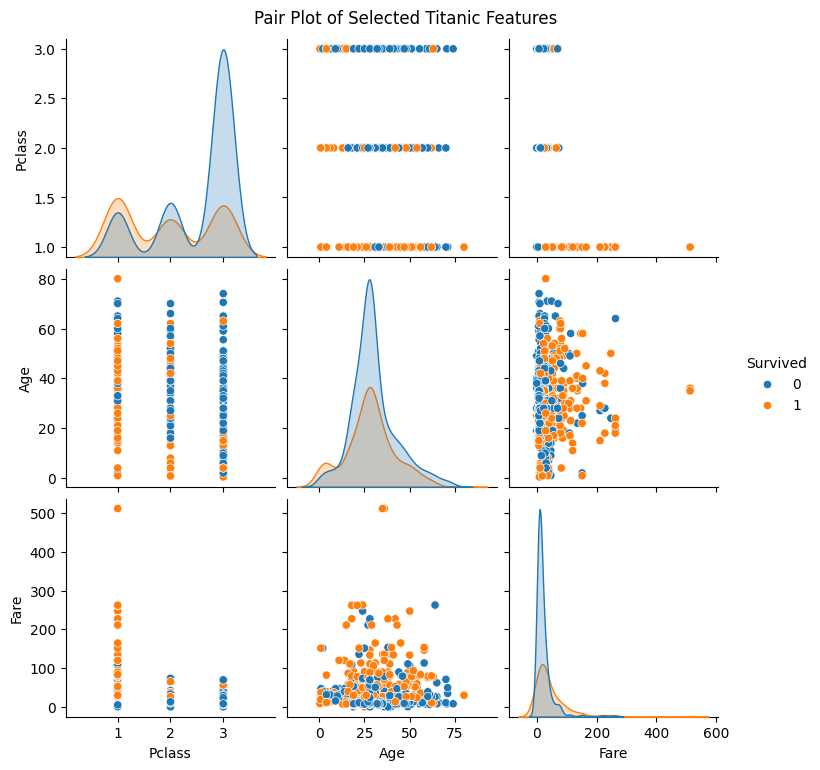

In [15]:
# Pair plot of selected features

selected_features = df[
    ["Survived", "Pclass", "Age", "Fare"]
]

sns.pairplot(selected_features, hue="Survived")

plt.suptitle("Pair Plot of Selected Titanic Features", y=1.02)
plt.show()

Task 8: Analyze survival rates by sex and passenger class

,Sex,Pclass,Survived
0,female,1,0.968085
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


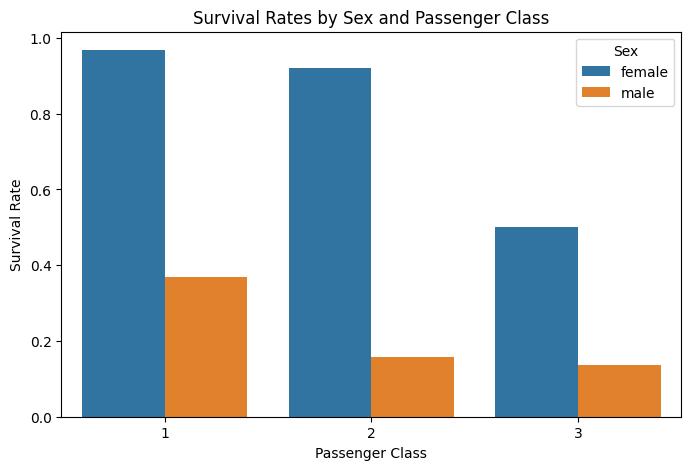

In [16]:
# Analyze survival rates by sex and passenger class

survival_analysis = df.groupby(
    ["Sex", "Pclass"]
)["Survived"].mean().reset_index()

display(survival_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=survival_analysis,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rates by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

Task 9: Analyze age distribution using a box plot

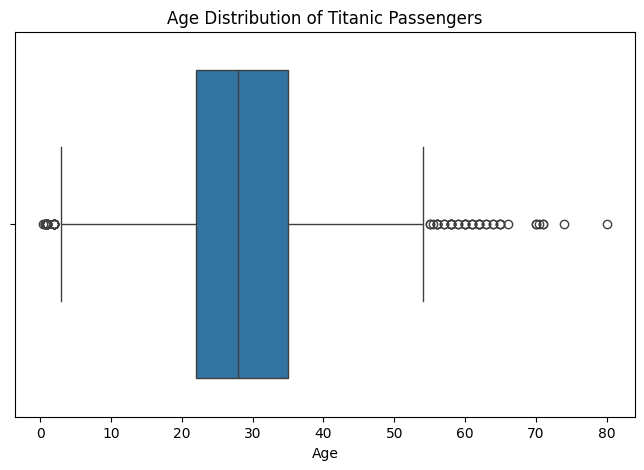

In [17]:
# Analyze age distribution using a box plot

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Age"])

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.show()

Task 10: Analyze fare distribution using a violin plot

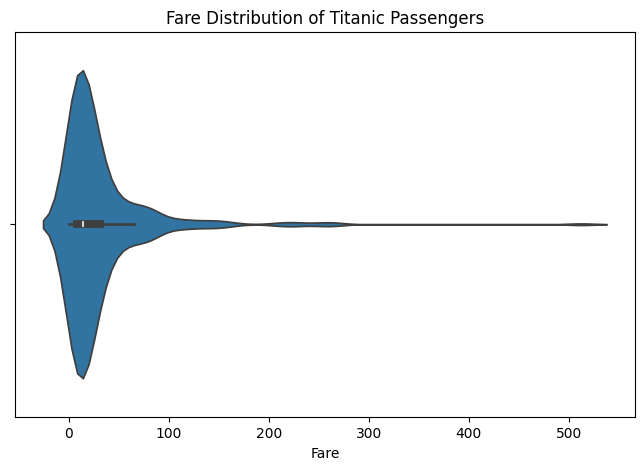

In [18]:
# Analyze fare distribution using a violin plot

plt.figure(figsize=(8, 5))

sns.violinplot(x=df["Fare"])

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")
plt.show()

## EDA Insights

After exploring the Titanic dataset, I noticed some clear patterns. Female passengers had a much higher chance of survival than male passengers. Passenger class also made a difference, as people in first class had a higher survival rate compared to those in second and third class.

Most of the passengers were young or middle-aged adults, although there were passengers from many different age groups. I also noticed that most passengers paid lower fares, while only a small number paid very high fares.

Overall, this analysis helped me understand how factors such as sex and passenger class were strongly connected to survival on the Titanic.